# Libraries

In [165]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [166]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240513 - Ag60 GDE_0.3 M Na2SO4_pH2

11-Aug-26  07:22 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
06-Jun-26  07:41 PM    <DIR>          .ipynb_checkpoints
14-May-24  10:31 AM            33,932 0p3M_pH2 Na2SO4_20240514_0830_1min - Copy.xlsx
03-Aug-26  03:36 PM            48,449 0p3M_pH2 Na2SO4_20240514_0830_1min.xlsx
14-May-24  10:30 AM           259,281 0p3M_pH2 Na2SO4_20240514_0830_Line_1.csv
03-Jun-26  09:05 AM           912,316 20240513 - Ag60 GDE_0.3 M Na2SO4_pH2.ipynb
11-Aug-26  07:22 AM           809,206 20240513 - Ag60 GDE_0.3 M Na2SO4_pH2-CORRECTED.ipynb
10-Aug-26  07:28 PM               602 20240513_0.3 M Na2SO4_pH2_Energy Consumption.csv
11-Aug-26  07:21 AM             5,779 20240513_0.3M Na2SO4_pH2.csv
10-Aug-26  07:28 PM               752 20240513_0.3M Na2SO4_pH2_flow rate.csv
06-Jun-26  07:40 PM           142,181 

# Load Data

In [207]:
Book = "Book_20240513 - Ag60 GDE_0.3 M Na2SO4_pH2.xlsx"
Book = pd.read_excel(Book)
Book.tail(10)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
72,-2,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,-2,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74,-3,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75,-3,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76,-3,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,-3,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,-3,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79,-3,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,-3,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81,-3,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [208]:
# Book["FE(CO)"] = round(Book["FE(CO)"]*100,2)
# Book["FE(H2)"] = round(Book["FE(H2)"]*100,2)
Book.head(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60.0,54.211966,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 16:24:00,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0
1,Ag60 GDE in PTFE holder,60.0,53.503743,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 16:33:00,0.15,0.298704,...,0.002856,0.004018,0.824082,0.035015,0.161823,0.227616,NaN,0.389439,0.004852,NaN
2,Ag60 GDE in PTFE holder,60.0,57.611278,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 17:09:00,0.75,0.673078,...,0.006511,0.009804,0.977213,0.001930,0.397181,0.598062,NaN,0.995243,0.009933,NaN


In [209]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
79,-3,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,-3,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81,-3,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Temp from pH meter

In [210]:
Temp = "2024-05-14_103043.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 24.129708826205643
Temp C median: 24.0


## Power supply/

In [211]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.14V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,13.05.2024 16:24:32.089
1,40.00V,3.11V,0.100A,0.116A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,13.05.2024 16:24:37.084


In [212]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set            
0.000A 0    0.14V
0.100A 1    3.11V
       2    3.28V

In [213]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                 Time  I actual  U actual
0 2024-05-13 16:00:00     0.124      3.54
1 2024-05-13 18:00:00     0.270      4.39
2 2024-05-13 20:00:00     0.517      5.40
3 2024-05-13 22:00:00     0.770      6.30
4 2024-05-14 00:00:00     1.020      7.02
5 2024-05-14 02:00:00     1.515      8.38
6 2024-05-14 04:00:00     2.020      9.47
7 2024-05-14 06:00:00     3.017     12.02
8 2024-05-14 08:00:00     3.017     11.60
9 2024-05-14 10:00:00     1.515      8.06


In [214]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-2].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-05-13 16:00:00     0.124      3.54
1 2024-05-13 18:00:00     0.270      4.39
2 2024-05-13 20:00:00     0.517      5.40
3 2024-05-13 22:00:00     0.770      6.30
4 2024-05-14 00:00:00     1.020      7.02
5 2024-05-14 02:00:00     1.515      8.38
6 2024-05-14 04:00:00     2.020      9.47
7 2024-05-14 06:00:00     3.017     12.02


In [215]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [216]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.124,3.54
0.270,4.39
0.517,5.40
0.770,6.30
1.020,7.02
1.515,8.38
2.020,9.47
3.017,12.02


In [217]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.124,3.54,1.24
0.270,4.39,2.70
0.517,5.40,5.17
0.770,6.30,7.70
1.020,7.02,10.20
1.515,8.38,15.15
2.020,9.47,20.20
3.017,12.02,30.17


## Flow rate

In [218]:
flow_rate = "0p3M_pH2 Na2SO4_20240514_0830_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-05-14 08:30:23.875000,NaN
1,Software version,Aurora 1.0.6,NaN
2,Instrument name,0p3M_pH2 Na2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6f:0d:ec,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [219]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-05-13 14:24:00,54.211966,27.105983
1,2024-05-13 14:24:59.962000,53.585808,26.792904
2,2024-05-13 14:26:00.010000,53.760736,26.880368
3,2024-05-13 14:26:59.971000,53.856482,26.928241
4,2024-05-13 14:28:00.019000,53.170165,26.585083
...,...,...,...
1012,2024-05-14 07:16:00.019000,68.082715,34.041358
1013,2024-05-14 07:16:59.981000,68.43018,34.21509
1014,2024-05-14 07:18:00.029000,68.739203,34.369602
1015,2024-05-14 07:18:59.990000,67.727689,33.863844


In [220]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-05-13 14:00:00     52.696587     60.448839      56.804225   
1 2024-05-13 16:00:00     59.126003     62.998566      61.253686   
2 2024-05-13 18:00:00     61.037113       64.1214      62.730676   
3 2024-05-13 20:00:00     61.525602     65.332734      63.644932   
4 2024-05-13 22:00:00     62.219985     66.675267      64.928718   
5 2024-05-14 00:00:00     63.911928     70.437457      68.359657   
6 2024-05-14 02:00:00     67.591578     75.395291      72.538385   
7 2024-05-14 04:00:00     71.964809     84.553193      79.921917   
8 2024-05-14 06:00:00      64.97726     82.247287      71.351162   

  Flow_rate_median  
0        57.299456  
1        61.388451  
2        62.675156  
3        63.706102  
4        65.104422  
5        69.109756  
6         73.19984  
7        81.395797  
8        67.881828  


### Correction dry flow

In [221]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.382 L/mol
p_sat = 2.9845 kPa -> x(H2O) = 2.95 % -> dry factor 0.97055


In [222]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [223]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-1].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-05-13 14:00:00,52.696587,60.448839,56.804225,57.299456,51.14443,58.668343,55.131079,55.611723,0.124,3.54
1,2024-05-13 16:00:00,59.126003,62.998566,61.253686,61.388451,57.38447,61.142968,59.449483,59.580278,0.270,4.39
2,2024-05-13 18:00:00,61.037113,64.1214,62.730676,62.675156,59.239289,62.23273,60.882969,60.829084,0.517,5.40
3,2024-05-13 20:00:00,61.525602,65.332734,63.644932,63.706102,59.71339,63.408384,61.770296,61.829664,0.770,6.30
4,2024-05-13 22:00:00,62.219985,66.675267,64.928718,65.104422,60.38732,64.711374,63.016268,63.186798,1.020,7.02
5,2024-05-14 00:00:00,63.911928,70.437457,68.359657,69.109756,62.029428,68.36275,66.34615,67.074156,1.515,8.38
6,2024-05-14 02:00:00,67.591578,75.395291,72.538385,73.19984,65.600695,73.174553,70.401796,71.043768,2.020,9.47
7,2024-05-14 04:00:00,71.964809,84.553193,79.921917,81.395797,69.845114,82.062712,77.567849,78.998316,3.017,12.02


In [226]:
# dfflow_rate.to_csv('20240513_0.3M Na2SO4_pH2_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J <br>

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [227]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.124,3.54,1.24,124.0
0.270,4.39,2.70,270.0
0.517,5.40,5.17,517.0


In [228]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.124,3.54,1.24,124.0,3160.512
0.270,4.39,2.70,270.0,8534.160
0.517,5.40,5.17,517.0,20100.960
0.770,6.30,7.70,770.0,34927.200
1.020,7.02,10.20,1020.0,51554.880
1.515,8.38,15.15,1515.0,91409.040
2.020,9.47,20.20,2020.0,137731.680
3.017,12.02,30.17,3017.0,261103.248


In [229]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.124,3.54,1.24,124.0,3160.512,0.000878
0.270,4.39,2.70,270.0,8534.160,0.002371
0.517,5.40,5.17,517.0,20100.960,0.005584
0.770,6.30,7.70,770.0,34927.200,0.009702
1.020,7.02,10.20,1020.0,51554.880,0.014321
1.515,8.38,15.15,1515.0,91409.040,0.025391
2.020,9.47,20.20,2020.0,137731.680,0.038259
3.017,12.02,30.17,3017.0,261103.248,0.072529


In [232]:
# dfcell_voltage.to_csv('20240513_0.3 M Na2SO4_pH2_Energy Consumption.csv')

## Integer Duration ("Applied Current /A" - Values optimization)

In [233]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60.0,54.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 16:24:00,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0,54.21,0.0
1,Ag60 GDE in PTFE holder,60.0,53.50,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 16:33:00,0.15,0.298704,...,0.824082,0.035015,0.161823,0.227616,NaN,0.389439,0.004852,NaN,53.50,0.0
2,Ag60 GDE in PTFE holder,60.0,57.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 17:09:00,0.75,0.673078,...,0.977213,0.001930,0.397181,0.598062,NaN,0.995243,0.009933,NaN,57.61,0.0
3,Ag60 GDE in PTFE holder,60.0,58.81,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 17:43:00,1.32,0.642794,...,0.980810,0.001069,0.388244,0.606497,NaN,0.994740,0.009833,NaN,58.81,1.0
4,Ag60 GDE in PTFE holder,60.0,60.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 18:11:00,1.78,0.671278,...,0.981934,0.000801,0.417100,0.587373,NaN,1.004473,0.009280,NaN,60.32,1.0
5,Ag60 GDE in PTFE holder,60.0,60.83,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 18:47:00,2.38,0.439343,...,0.967019,0.000634,0.127891,0.800752,NaN,0.928643,0.027022,NaN,60.83,2.0
6,Ag60 GDE in PTFE holder,60.0,61.30,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 19:14:00,2.83,0.453573,...,0.966050,0.000582,0.132906,0.836148,NaN,0.969054,0.027996,NaN,61.30,2.0
7,Ag60 GDE in PTFE holder,60.0,61.77,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 19:40:00,3.27,0.497431,...,0.966543,0.000496,0.147237,0.823886,NaN,0.971123,0.027382,NaN,61.77,3.0
8,Ag60 GDE in PTFE holder,60.0,62.27,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 20:07:00,3.72,0.531468,...,0.966845,0.000447,0.158384,0.816531,NaN,0.974915,0.026923,NaN,62.27,3.0
9,Ag60 GDE in PTFE holder,60.0,63.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-05-13 20:33:00,4.15,0.789049,...,0.953965,0.000440,0.125121,0.601196,NaN,0.726316,0.037467,NaN,63.61,4.0


# Current density

In [234]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60.0,54.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 16:24:00,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0,54.21,0.0,-125.0
1,Ag60 GDE in PTFE holder,60.0,53.50,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 16:33:00,0.15,0.298704,...,0.035015,0.161823,0.227616,NaN,0.389439,0.004852,NaN,53.50,0.0,-125.0
2,Ag60 GDE in PTFE holder,60.0,57.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 17:09:00,0.75,0.673078,...,0.001930,0.397181,0.598062,NaN,0.995243,0.009933,NaN,57.61,0.0,-125.0
3,Ag60 GDE in PTFE holder,60.0,58.81,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 17:43:00,1.32,0.642794,...,0.001069,0.388244,0.606497,NaN,0.994740,0.009833,NaN,58.81,1.0,-125.0
4,Ag60 GDE in PTFE holder,60.0,60.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 18:11:00,1.78,0.671278,...,0.000801,0.417100,0.587373,NaN,1.004473,0.009280,NaN,60.32,1.0,-125.0
5,Ag60 GDE in PTFE holder,60.0,60.83,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 18:47:00,2.38,0.439343,...,0.000634,0.127891,0.800752,NaN,0.928643,0.027022,NaN,60.83,2.0,-270.0
6,Ag60 GDE in PTFE holder,60.0,61.30,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 19:14:00,2.83,0.453573,...,0.000582,0.132906,0.836148,NaN,0.969054,0.027996,NaN,61.30,2.0,-270.0
7,Ag60 GDE in PTFE holder,60.0,61.77,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 19:40:00,3.27,0.497431,...,0.000496,0.147237,0.823886,NaN,0.971123,0.027382,NaN,61.77,3.0,-270.0
8,Ag60 GDE in PTFE holder,60.0,62.27,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 20:07:00,3.72,0.531468,...,0.000447,0.158384,0.816531,NaN,0.974915,0.026923,NaN,62.27,3.0,-270.0
9,Ag60 GDE in PTFE holder,60.0,63.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-05-13 20:33:00,4.15,0.789049,...,0.000440,0.125121,0.601196,NaN,0.726316,0.037467,NaN,63.61,4.0,-520.0


## FE(CO)

In [235]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [236]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.382 L/mol


In [237]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.124, 0.27, 0.517, 0.77, 1.02, 1.515, 2.02, 3.017]

In [238]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[5, 4, 5, 4, 5, 4, 5, 4]

In [239]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))

                     c(H2)  c(CO)
Applied current / A              
0.124                0.006  0.009
0.270                0.005  0.027
0.517                0.010  0.049
0.770                0.022  0.061
1.020                0.039  0.069
1.515                0.081  0.072
2.020                0.131  0.067
3.017                0.213  0.058


In [240]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    # # Debug
    # debug = pd.DataFrame({
    #     'current_A'   : current_A.abs(),
    #     'conc'        : conc,
    #     'flow_ml_min' : flow_ml_min,
    #     'flow_L_s'    : flow_L_s,
    #     'mol_per_s'   : mol_per_s,
    #     'charge_rate' : charge_rate,
    #     'FE'          : FE
    # })
    # print(debug.to_string())
    # print("---")
    return FE

# rows["FE(CO)"] = faradaic_efficiency(
#     rows["c(CO)"], 
#     rows["Flow rate (ml min-1)"], 
#     rows["Applied current / A"])

# rows["FE(H2)"] = faradaic_efficiency(
#     rows["c(H2)"], 
#     rows["Flow rate (ml min-1)"], 
#     rows["Applied current / A"])


rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 96.5 / 85.5 %


In [241]:
Book.head(5)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60.0,54.21,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 16:24:00,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.0,54.21,0.0,-125.0
1,Ag60 GDE in PTFE holder,60.0,53.50,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 16:33:00,0.15,0.298704,...,0.035015,0.161823,0.227616,NaN,0.389439,0.004852,NaN,53.50,0.0,-125.0
2,Ag60 GDE in PTFE holder,60.0,57.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 17:09:00,0.75,0.673078,...,0.001930,0.397181,0.598062,NaN,0.995243,0.009933,NaN,57.61,0.0,-125.0
3,Ag60 GDE in PTFE holder,60.0,58.81,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 17:43:00,1.32,0.642794,...,0.001069,0.388244,0.606497,NaN,0.994740,0.009833,NaN,58.81,1.0,-125.0
4,Ag60 GDE in PTFE holder,60.0,60.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-05-13 18:11:00,1.78,0.671278,...,0.000801,0.417100,0.587373,NaN,1.004473,0.009280,NaN,60.32,1.0,-125.0


In [242]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 0.15].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
2,Ag60 GDE in PTFE holder,60.0,57.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-05-13 17:09:00,0.75,0.673078,...,57.61,0.0,-124.0,0.125,0.124,55.131079,51.14443,58.668343,55.611723,96.519097
3,Ag60 GDE in PTFE holder,60.0,58.81,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-05-13 17:43:00,1.32,0.642794,...,58.81,1.0,-124.0,0.125,0.124,55.131079,51.14443,58.668343,55.611723,94.504289
4,Ag60 GDE in PTFE holder,60.0,60.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-05-13 18:11:00,1.78,0.671278,...,60.32,1.0,-124.0,0.125,0.124,55.131079,51.14443,58.668343,55.611723,93.045535
5,Ag60 GDE in PTFE holder,60.0,60.83,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 18:47:00,2.38,0.439343,...,60.83,2.0,-270.0,0.270,0.270,59.449483,57.38447,61.142968,59.580278,90.657120
6,Ag60 GDE in PTFE holder,60.0,61.30,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 19:14:00,2.83,0.453573,...,61.30,2.0,-270.0,0.270,0.270,59.449483,57.38447,61.142968,59.580278,93.864768
7,Ag60 GDE in PTFE holder,60.0,61.77,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 19:40:00,3.27,0.497431,...,61.77,3.0,-270.0,0.270,0.270,59.449483,57.38447,61.142968,59.580278,93.358768
8,Ag60 GDE in PTFE holder,60.0,62.27,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 20:07:00,3.72,0.531468,...,62.27,3.0,-270.0,0.270,0.270,59.449483,57.38447,61.142968,59.580278,92.968266
9,Ag60 GDE in PTFE holder,60.0,63.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.517,2024-05-13 20:33:00,4.15,0.789049,...,63.61,4.0,-517.0,0.520,0.517,60.882969,59.239289,62.23273,60.829084,69.624304
10,Ag60 GDE in PTFE holder,60.0,63.47,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.517,2024-05-13 21:00:00,4.60,0.996210,...,63.47,4.0,-517.0,0.520,0.517,60.882969,59.239289,62.23273,60.829084,87.994372
11,Ag60 GDE in PTFE holder,60.0,63.19,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.517,2024-05-13 21:26:00,5.03,0.986204,...,63.19,5.0,-517.0,0.520,0.517,60.882969,59.239289,62.23273,60.829084,90.969107


### Mean FE per current density

In [243]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        124   38.013319   56.676321     38.518778     57.619599   0.565337   
1        270   13.654233   79.057998     13.514103     78.688045   0.600497   
2        517   14.433880   71.617175     15.026352     75.818217   0.610743   
3        770   22.782406   64.751285     22.976592     65.064271   0.317117   
4       1020   30.630159   55.654302     31.748173     56.071502   1.558496   
5       1515   47.090635   41.855834     47.559919     42.028549   1.181309   
6       2020   57.894681   30.491911     60.653316     30.910612   2.851882   
7       3017   73.133169   19.964534     73.572120     19.978656   0.999613   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0   1.138953   0.979192   1.972724  37.701734  ...   0.006426     0.006511  3   
1   0.705199   1.200995   1.410398  12.776463  ...   0.004691     0.004643  4   
2   3.544664   1.365663   7.926111  14.942577

## FE(H2)

In [244]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [245]:
print(rows["FE(H2)"])

2     38.518778
3     36.884690
4     38.636489
5     12.485157
6     12.873565
7     14.154640
8     15.103570
9     11.994014
10    15.129182
11    15.026352
12    14.942577
13    15.077278
14    23.072317
15    23.308495
16    21.867944
17    22.880867
18    24.588305
19    31.009726
20    31.748173
21    32.481009
22    33.323582
23    49.362540
24    48.206737
25    43.880163
26    46.913101
27    46.769188
28    58.511132
29    60.653316
30    61.112787
31    62.426980
32    74.155188
33    70.398562
34    72.989052
35    74.989874
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

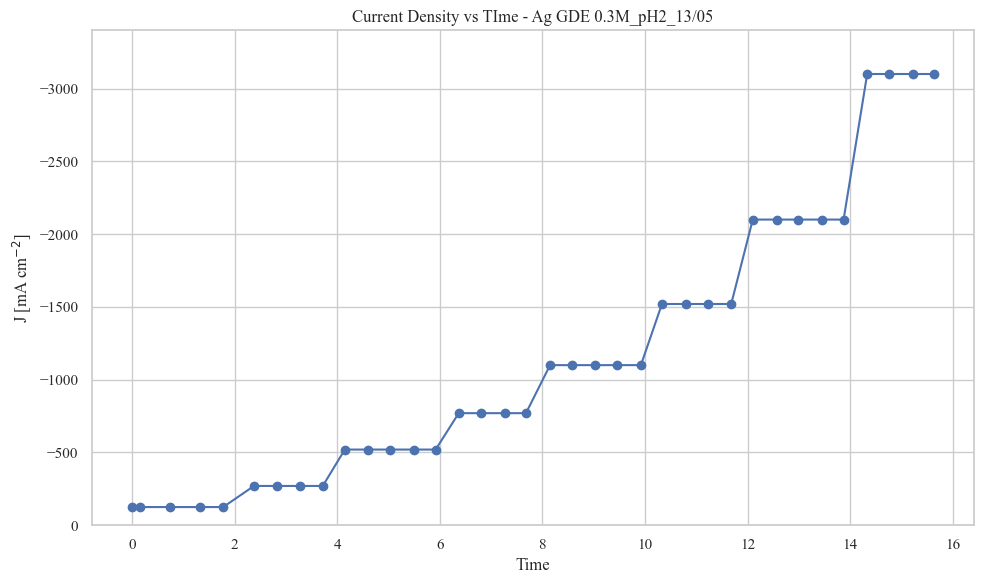

In [246]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.3M_pH2_13/05')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

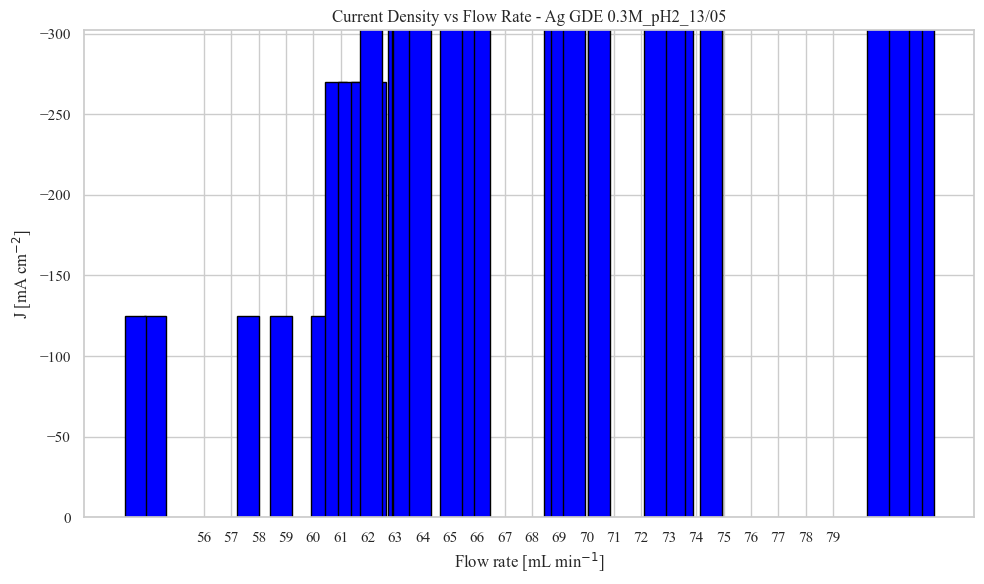

In [247]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Current Density'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.3M_pH2_13/05')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -302)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


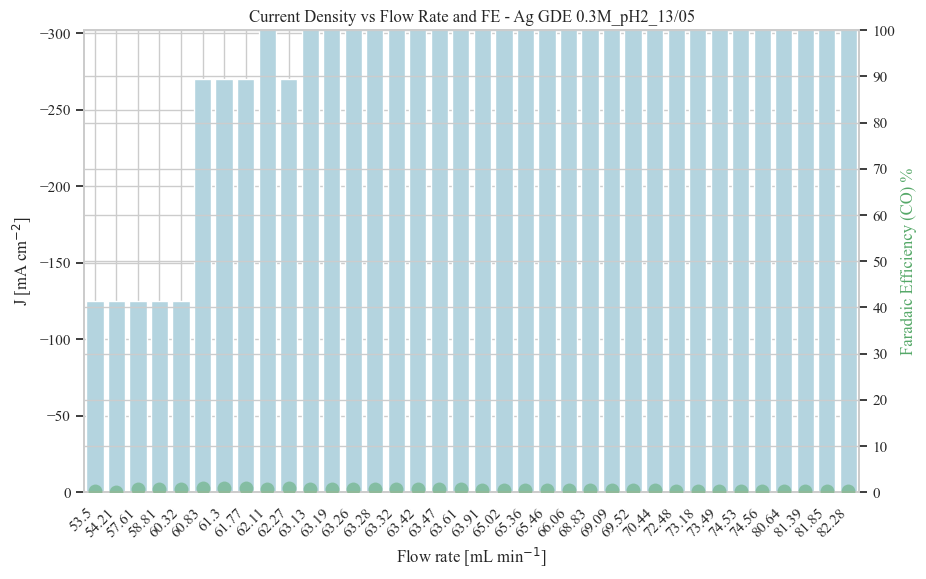

In [248]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Current Density', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.3M_pH2_13/05')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [mA cm$^{-2}$]')
ax1.set_ylim(0, -302)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240513_Ag_GDE_0_3M_pH2_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [249]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [250]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240513 - Ag60 GDE_0.3 M Na2SO4_pH2

11-Aug-26  08:19 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
06-Jun-26  07:41 PM    <DIR>          .ipynb_checkpoints
14-May-24  10:31 AM            33,932 0p3M_pH2 Na2SO4_20240514_0830_1min - Copy.xlsx
03-Aug-26  03:36 PM            48,449 0p3M_pH2 Na2SO4_20240514_0830_1min.xlsx
14-May-24  10:30 AM           259,281 0p3M_pH2 Na2SO4_20240514_0830_Line_1.csv
03-Jun-26  09:05 AM           912,316 20240513 - Ag60 GDE_0.3 M Na2SO4_pH2.ipynb
11-Aug-26  08:19 AM           812,044 20240513 - Ag60 GDE_0.3 M Na2SO4_pH2-CORRECTED.ipynb
11-Aug-26  08:19 AM               602 20240513_0.3 M Na2SO4_pH2_Energy Consumption.csv
11-Aug-26  07:21 AM             5,779 20240513_0.3M Na2SO4_pH2.csv
11-Aug-26  08:19 AM             1,413 20240513_0.3M Na2SO4_pH2_flow rate.csv
06-Jun-26  07:40 PM           142,181 

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


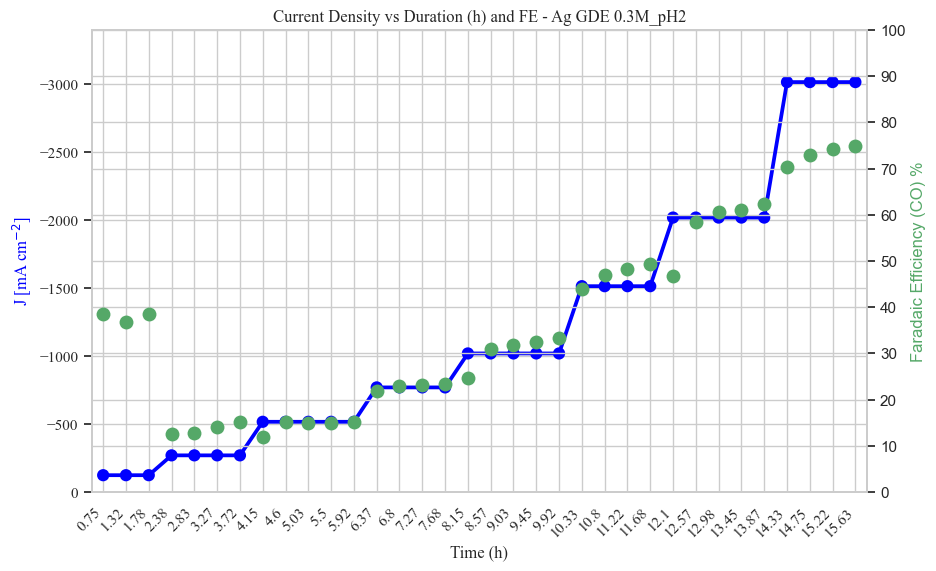

In [251]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.3M_pH2')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(H2)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240513_Ag_GDE_0_3M_pH2_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### Drop point from inital step in each current

In [252]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 0.15].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
2,Ag60 GDE in PTFE holder,60.0,57.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-05-13 17:09:00,0.75,0.673078,...,57.61,0.0,-124.0,0.125,0.124,55.131079,51.14443,58.668343,55.611723,96.519097
3,Ag60 GDE in PTFE holder,60.0,58.81,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-05-13 17:43:00,1.32,0.642794,...,58.81,1.0,-124.0,0.125,0.124,55.131079,51.14443,58.668343,55.611723,94.504289
4,Ag60 GDE in PTFE holder,60.0,60.32,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-05-13 18:11:00,1.78,0.671278,...,60.32,1.0,-124.0,0.125,0.124,55.131079,51.14443,58.668343,55.611723,93.045535
5,Ag60 GDE in PTFE holder,60.0,60.83,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 18:47:00,2.38,0.439343,...,60.83,2.0,-270.0,0.270,0.270,59.449483,57.38447,61.142968,59.580278,90.657120
6,Ag60 GDE in PTFE holder,60.0,61.30,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 19:14:00,2.83,0.453573,...,61.30,2.0,-270.0,0.270,0.270,59.449483,57.38447,61.142968,59.580278,93.864768
7,Ag60 GDE in PTFE holder,60.0,61.77,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 19:40:00,3.27,0.497431,...,61.77,3.0,-270.0,0.270,0.270,59.449483,57.38447,61.142968,59.580278,93.358768
8,Ag60 GDE in PTFE holder,60.0,62.27,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-05-13 20:07:00,3.72,0.531468,...,62.27,3.0,-270.0,0.270,0.270,59.449483,57.38447,61.142968,59.580278,92.968266
9,Ag60 GDE in PTFE holder,60.0,63.61,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.517,2024-05-13 20:33:00,4.15,0.789049,...,63.61,4.0,-517.0,0.520,0.517,60.882969,59.239289,62.23273,60.829084,69.624304
10,Ag60 GDE in PTFE holder,60.0,63.47,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.517,2024-05-13 21:00:00,4.60,0.996210,...,63.47,4.0,-517.0,0.520,0.517,60.882969,59.239289,62.23273,60.829084,87.994372
11,Ag60 GDE in PTFE holder,60.0,63.19,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.517,2024-05-13 21:26:00,5.03,0.986204,...,63.19,5.0,-517.0,0.520,0.517,60.882969,59.239289,62.23273,60.829084,90.969107


## Current Density vs FE(CO)_ mean and std

## Stacked bar plot

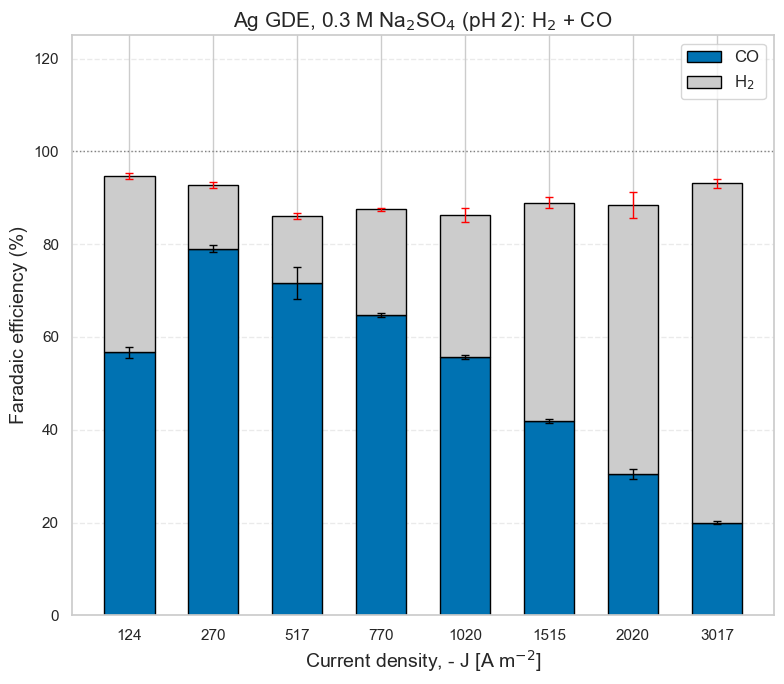

In [253]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.3 M Na$_2$SO$_4$ (pH 2): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

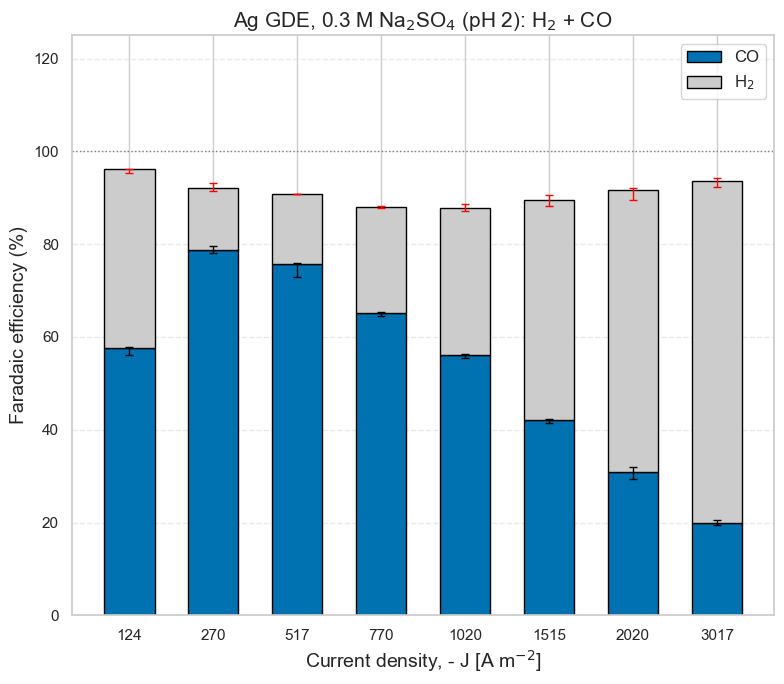

In [256]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.3 M Na$_2$SO$_4$ (pH 2): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [257]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [258]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,38.013319,56.676321,38.518778,57.619599,0.565337,1.138953,0.979192,1.972724,37.701734,...,0.006511,3,0.817044,0.058855,1.605276,0.190360,0.729377,1.007404,0–2,124
1,250,13.654233,79.057998,13.514103,78.688045,0.600497,0.705199,1.200995,1.410398,12.776463,...,0.004643,4,0.737640,0.877770,0.592899,0.962851,0.773038,0.321751,2–4,270
2,500,14.433880,71.617175,15.026352,75.818217,0.610743,3.544664,1.365663,7.926111,14.942577,...,0.009682,5,0.083775,0.050926,2.953028,0.011207,2.766422,0.145908,4–6,517
3,750,22.782406,64.751285,22.976592,65.064271,0.317117,0.460928,0.634233,0.921855,22.627636,...,0.021693,4,0.348956,0.154770,0.529645,0.216659,0.878601,0.371428,6–8,770
4,1000,30.630159,55.654302,31.748173,56.071502,1.558496,0.457570,3.484903,1.023157,31.009726,...,0.038853,5,0.738448,0.732836,0.603848,0.258411,0.619846,0.474426,8–10,1020
5,1500,47.090635,41.855834,47.559919,42.028549,1.181309,0.411238,2.362618,0.822475,46.154866,...,0.081438,4,1.405053,0.935769,0.486476,0.313762,1.091291,0.449293,10–12,1515
6,2000,57.894681,30.491911,60.653316,30.910612,2.851882,1.144761,6.377002,2.559764,58.511132,...,0.130741,5,2.142184,0.459471,1.596359,1.059779,3.027920,1.259710,12–14,2020
7,3000,73.133169,19.964534,73.572120,19.978656,0.999613,0.332797,1.999227,0.665595,72.341429,...,0.213011,4,1.230691,0.791740,0.493320,0.479197,0.751493,0.298420,14–16,3017


In [259]:
Res_Book
# Res_Book.to_csv('20240513_0.3M Na2SO4_pH2.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,38.013319,56.676321,38.518778,57.619599,0.565337,1.138953,0.979192,1.972724,37.701734,...,0.006511,3,0.817044,0.058855,1.605276,0.190360,0.729377,1.007404,0–2,124
1,250,13.654233,79.057998,13.514103,78.688045,0.600497,0.705199,1.200995,1.410398,12.776463,...,0.004643,4,0.737640,0.877770,0.592899,0.962851,0.773038,0.321751,2–4,270
2,500,14.433880,71.617175,15.026352,75.818217,0.610743,3.544664,1.365663,7.926111,14.942577,...,0.009682,5,0.083775,0.050926,2.953028,0.011207,2.766422,0.145908,4–6,517
3,750,22.782406,64.751285,22.976592,65.064271,0.317117,0.460928,0.634233,0.921855,22.627636,...,0.021693,4,0.348956,0.154770,0.529645,0.216659,0.878601,0.371428,6–8,770
4,1000,30.630159,55.654302,31.748173,56.071502,1.558496,0.457570,3.484903,1.023157,31.009726,...,0.038853,5,0.738448,0.732836,0.603848,0.258411,0.619846,0.474426,8–10,1020
5,1500,47.090635,41.855834,47.559919,42.028549,1.181309,0.411238,2.362618,0.822475,46.154866,...,0.081438,4,1.405053,0.935769,0.486476,0.313762,1.091291,0.449293,10–12,1515
6,2000,57.894681,30.491911,60.653316,30.910612,2.851882,1.144761,6.377002,2.559764,58.511132,...,0.130741,5,2.142184,0.459471,1.596359,1.059779,3.027920,1.259710,12–14,2020
7,3000,73.133169,19.964534,73.572120,19.978656,0.999613,0.332797,1.999227,0.665595,72.341429,...,0.213011,4,1.230691,0.791740,0.493320,0.479197,0.751493,0.298420,14–16,3017


## Mean and StD of FE(CO) through time

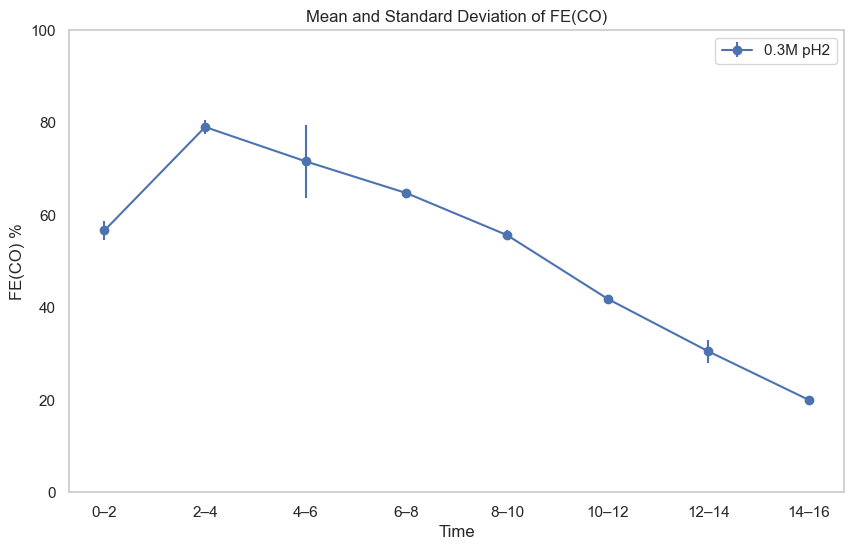

In [260]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Applied Current mean with standard deviation
# ax.errorbar(resampled_df.index, resampled_df['Applied current / A_mean'], 
#             yerr=resampled_df['Applied current / A_std'], fmt='-o', label='Applied current / A_mean')

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.3M pH2')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240513_0.3M_pH2_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

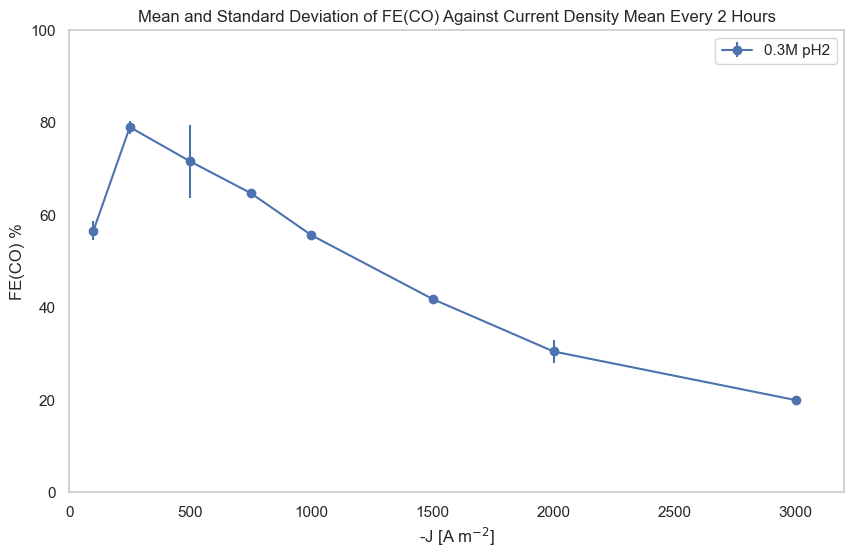

In [261]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.3M pH2')

# Formatting the plot
ax.set_xlabel(r'-J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3200)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240513_0.3M_pH2_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()

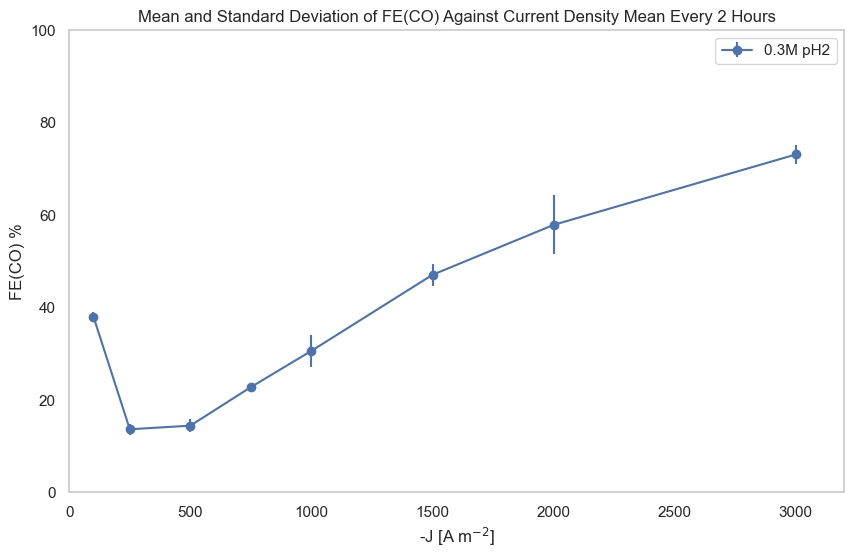

In [262]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(H2)_mean'], 
            yerr=Res_Book['FE(H2)_std'], fmt='-o', label='0.3M pH2')

# Formatting the plot
ax.set_xlabel(r'-J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3200)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240513_0.3M_pH2_mean_std_FE(H2)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()